### Applied Partial Differential Equations | Richard Haberman | Solutions and Code by David A. Lee
### Chapter 3: Fourier Series
#### Section 3.2: Statement of the Convergence Theorem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

Question 3.2.1

In [2]:
def style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=None, ylim=None,
             xticks=None, xticklabels=None, yticks=None, yticklabels=None,
             color='white', fontsize=16):
    """Apply shared plot attributes to one or more axes."""
    axes = np.atleast_1d(ax)
    for a in axes:
        a.set_xlabel(xlabel, color=color, fontsize=fontsize)
        a.set_ylabel(ylabel, color=color, fontsize=fontsize)
        a.tick_params(colors=color)
        a.tick_params(labelsize=fontsize)
        a.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
        a.grid(False)
        if xlim is not None:
            a.set_xlim(xlim)
        if ylim is not None:
            a.set_ylim(ylim)
        if xticks is not None:
            a.set_xticks(xticks)
        if xticklabels is not None:
            a.set_xticklabels(xticklabels, color=color)
        if yticks is not None:
            a.set_yticks(yticks)
        if yticklabels is not None:
            a.set_yticklabels(yticklabels, color=color)

In [3]:
L = 1.0
PERIODS = range(-2, 2)   # copies of (-L, L) covering [-3L, 3L]

L_ticks = [-3*L, -2*L, -L, 0, L, 2*L, 3*L]
L_labels = [r'$-3L$', r'$-2L$', r'$-L$', r'$0$', r'$L$', r'$2L$', r'$3L$']


def plot_fourier_series(pieces, label, fname, color, xticks=L_ticks, xticklabels=L_labels):
    """pieces: list of (a, b, g) with g smooth on (a, b); pieces partition (-L, L).

    Left: f(x) on [-L, L].  Right: what its Fourier series converges to on
    [-3L, 3L] -- the 2L-periodic extension of f, with the midpoint at every
    jump (open circles = one-sided limits, filled dot = average)."""
    plt.style.use(['science', 'scatter', 'dark_background'])
    fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 3]})

    # --- left: f itself on [-L, L]
    for a, b, g in pieces:
        x = np.linspace(a, b, 400)
        ax[0].plot(x, g(x), color=color, linewidth=2.5)
    ax[0].plot([], [], color=color, linewidth=2.5, label=label)

    # --- right: periodic extension
    vals = []
    for k in PERIODS:
        for a, b, g in pieces:
            x = np.linspace(a, b, 400)
            y = g(x)
            vals.append(y)
            ax[1].plot(x + 2*k*L, y, color=color, linewidth=2.5)
    ax[1].plot([], [], color=color, linewidth=2.5, label='periodic extension of ' + label)

    # --- jumps: one-sided limits at every piece boundary, incl. x = +-L
    lefts  = {b: g(b) for a, b, g in pieces}   # limit from the left at x = b
    rights = {a: g(a) for a, b, g in pieces}   # limit from the right at x = a
    lefts[-L], rights[L] = lefts[L], rights[-L]  # periodicity wraps the ends
    for x0 in sorted(rights):
        lo, hi = lefts[x0], rights[x0]
        if not np.isclose(lo, hi):
            for k in PERIODS:
                xs = x0 + 2*k*L
                if -3*L <= xs <= 3*L:
                    ax[1].plot([xs, xs], [lo, hi], color=color, linestyle=':', linewidth=1)
                    ax[1].plot([xs, xs], [lo, hi], 'o', color='black', markeredgecolor=color, markersize=6)
                    ax[1].plot(xs, (lo + hi)/2, 'o', color=color, markersize=6)

    # --- shared styling
    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    ylim = (v.min() - pad, v.max() + pad)
    inner = [i for i, t in enumerate(xticks) if abs(t) <= L]
    style_ax(ax[0], xlabel='$x$', ylabel='$f(x)$', xlim=(-L, L), ylim=ylim,
             xticks=[xticks[i] for i in inner], xticklabels=[xticklabels[i] for i in inner])
    style_ax(ax[1], xlabel='$x$', ylabel='', xlim=(-3*L, 3*L), ylim=ylim,
             xticks=xticks, xticklabels=xticklabels)
    ax[1].set_yticklabels([])
    for a in ax:
        a.axhline(0, color='white', linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower left', bbox_to_anchor=(0, 1.02))
    for k in range(-3, 4, 2):
        ax[1].axvline(k*L, color='white', linestyle='--', linewidth=1)

    fig.subplots_adjust(wspace=0.08)
    fig.savefig(fname, format='pdf')
    plt.show()

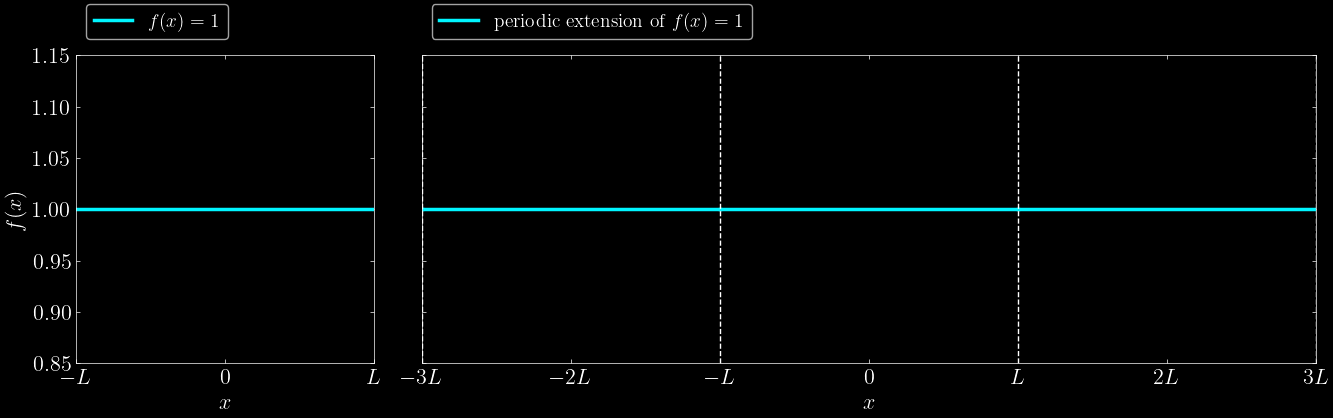

In [4]:
pieces = [(-L, L, lambda x: np.ones_like(x))]
plot_fourier_series(pieces, r"$f(x) = 1$", "chap3sec3.2ex1a.pdf", "#00F5FF")

(a) $f(x) = 1$ is already its own Fourier series (only $a_0 = 1$ is nonzero). Continuous periodic extension, so the series equals $f$ everywhere, endpoints included.

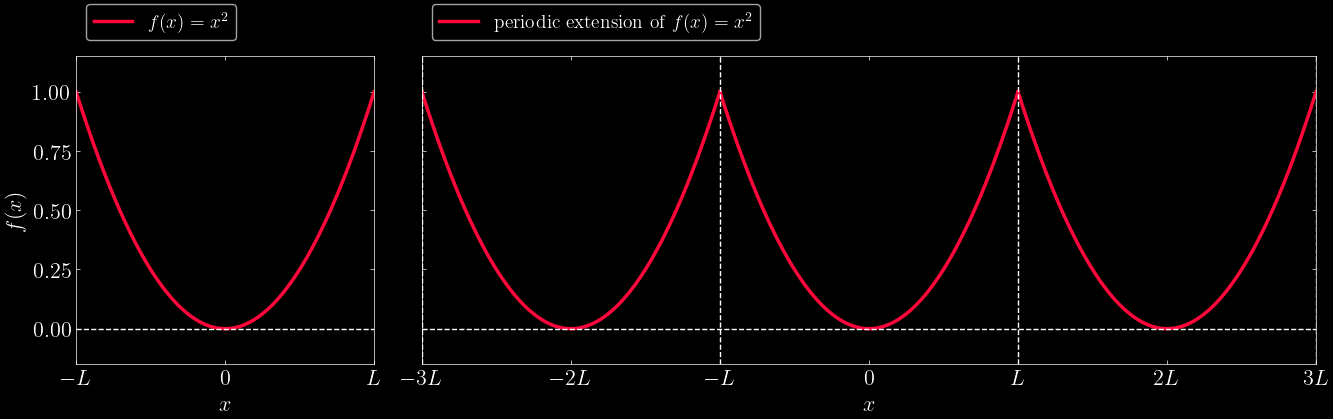

In [5]:
pieces = [(-L, L, lambda x: x**2)]
plot_fourier_series(pieces, r"$f(x) = x^{2}$", "chap3sec3.2ex1b.pdf", "#FF073A")

(b) $f(-L) = f(L) = L^2$, so the periodic extension is continuous (a scalloped, even curve). Fourier series equals $x^2$ on all of $[-L, L]$, with corners at $x = \pm L$.

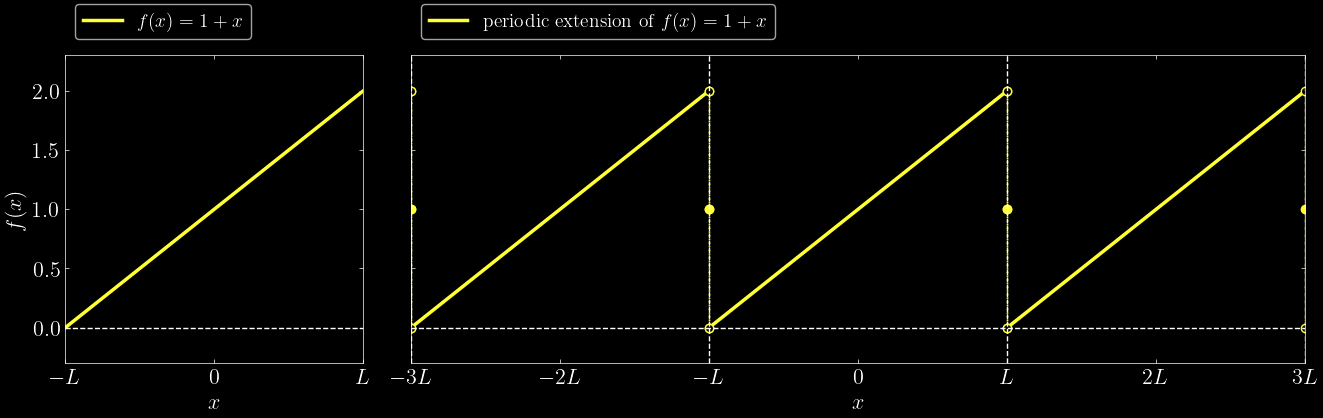

In [6]:
pieces = [(-L, L, lambda x: 1 + x)]
plot_fourier_series(pieces, r"$f(x) = 1 + x$", "chap3sec3.2ex1c.pdf", "#FFFF33")

(c) Sawtooth. Jump of $2L$ at $x = \pm L$; series converges to the average $\tfrac{1}{2}[(1 - L) + (1 + L)] = 1$ there, not to $f(\pm L)$. Elsewhere on $(-L, L)$ it equals $1 + x$.

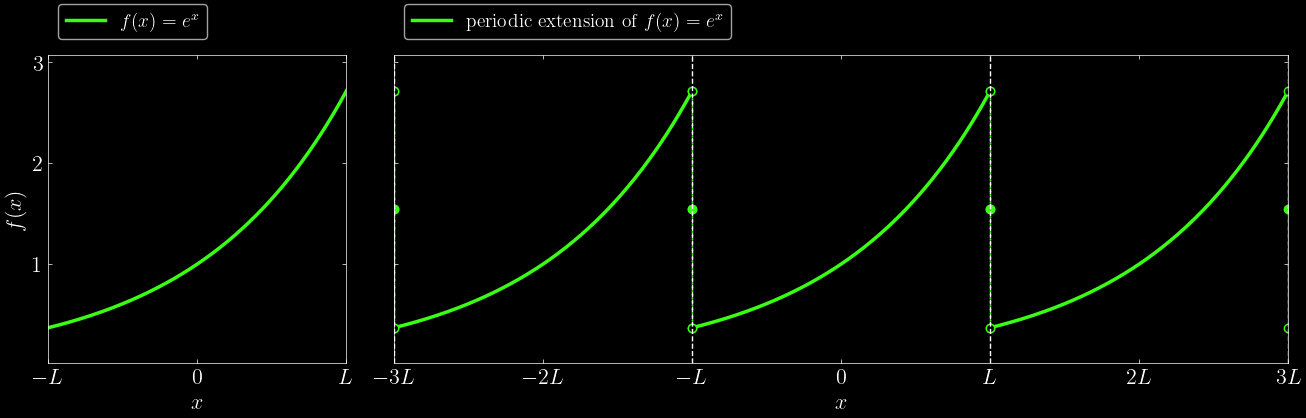

In [7]:
pieces = [(-L, L, lambda x: np.exp(x))]
plot_fourier_series(pieces, r"$f(x) = e^{x}$", "chap3sec3.2ex1d.pdf", "#39FF14")

(d) Jump at $x = \pm L$ from $e^{-L}$ to $e^{L}$; series converges to $\tfrac{1}{2}(e^{L} + e^{-L}) = \cosh L$ at the endpoints and to $e^x$ on the open interval $(-L, L)$.

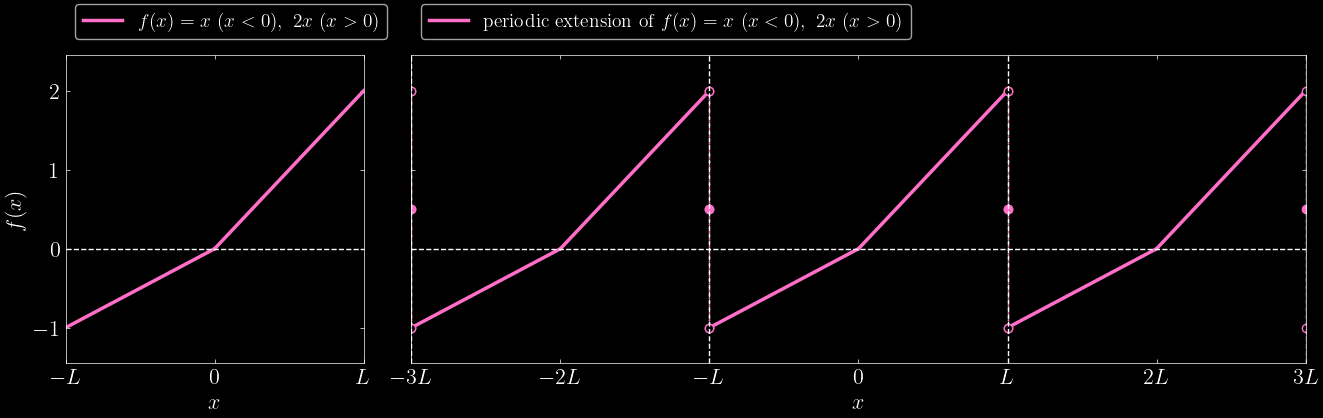

In [8]:
pieces = [(-L, 0, lambda x: x), (0, L, lambda x: 2*x)]
plot_fourier_series(pieces, r"$f(x) = x\ (x<0),\ 2x\ (x>0)$", "chap3sec3.2ex1e.pdf", "#FF6EC7")

(e) Continuous at $x = 0$ (both pieces vanish) with only a corner, so the series equals $f$ there. Jump at $x = \pm L$ from $f(L^-) = 2L$ down to $f(-L^+) = -L$; series converges to $\tfrac{1}{2}(2L - L) = L/2$ at $x = \pm L$.

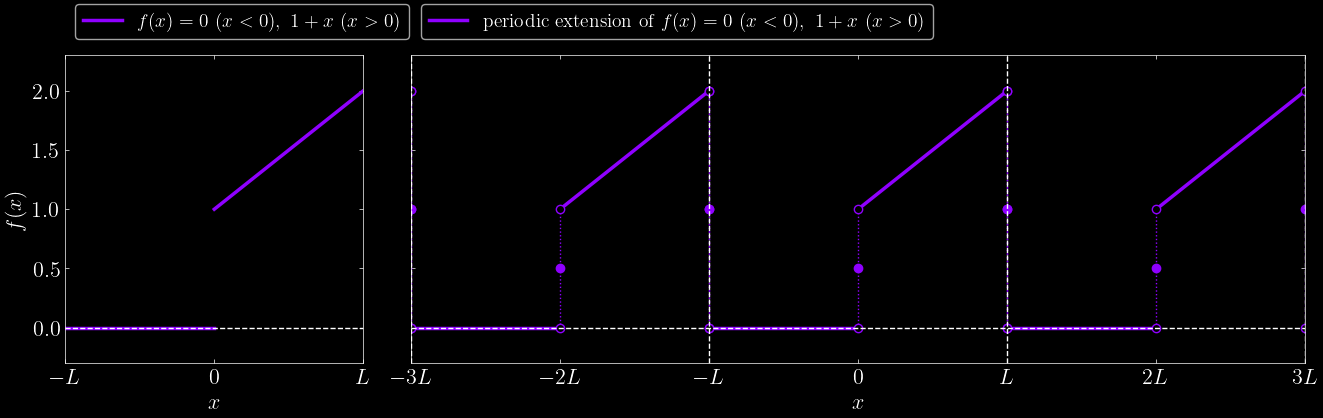

In [9]:
pieces = [(-L, 0, lambda x: np.zeros_like(x)), (0, L, lambda x: 1 + x)]
plot_fourier_series(pieces, r"$f(x) = 0\ (x<0),\ 1 + x\ (x>0)$", "chap3sec3.2ex1f.pdf", "#8F00FF")

(f) Two jumps per period. At $x = 0$: from $0$ to $1$, series gives $1/2$. At $x = \pm L$: from $f(L^-) = 1 + L$ to $f(-L^+) = 0$, series gives $(1 + L)/2$. Equals $f$ on the open pieces.

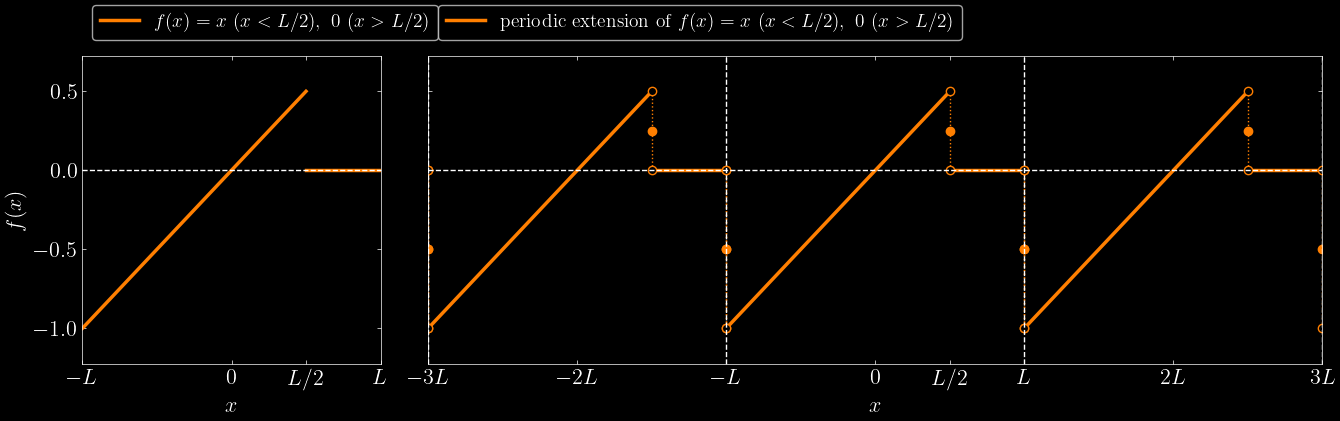

In [10]:
pieces = [(-L, L/2, lambda x: x), (L/2, L, lambda x: np.zeros_like(x))]
plot_fourier_series(pieces, r"$f(x) = x\ (x<L/2),\ 0\ (x>L/2)$", "chap3sec3.2ex1g.pdf", "#FF7F00",
                    xticks=sorted(L_ticks + [L/2]), xticklabels=L_labels[:4] + [r'$L/2$'] + L_labels[4:])

(g) Jump at $x = L/2$ from $L/2$ to $0$, series gives $L/4$. At $x = \pm L$: from $f(L^-) = 0$ to $f(-L^+) = -L$, series gives $-L/2$. Equals $f$ on the open pieces.